# Práctica guiada: Procesamiento digital de imágenes

Esta práctica funciona como puente entre los cuadernos conceptuales y el laboratorio aplicado. La propuesta es que completes código, pruebes variantes y expliques con tus palabras qué decisiones tomaste.

## Objetivos

- Recuperar ideas de color, canales, bordes e intensidad.
- Practicar lectura de imágenes con `OpenCV`.
- Resolver consignas breves con andamiaje.
- Prepararte para el laboratorio de segmentación y la actividad integradora.


In [2]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import skimage as ski


def mostrar_imagenes(imagenes, titulos, cmap=None, figsize=(14, 4)):
    fig, axes = plt.subplots(1, len(imagenes), figsize=figsize)
    if len(imagenes) == 1:
        axes = [axes]

    for ax, imagen, titulo in zip(axes, imagenes, titulos):
        if imagen.ndim == 2:
            ax.imshow(imagen, cmap=cmap or "gray")
        else:
            ax.imshow(imagen)
        ax.set_title(titulo)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def segmentar_por_umbral(imagen, umbral):
    mascara = np.zeros_like(imagen, dtype=np.uint8)
    mascara[imagen > umbral] = 255
    return mascara


In [3]:
base = Path(".")

cv2.imwrite(str(base / "paisaje.png"), cv2.cvtColor(ski.data.astronaut(), cv2.COLOR_RGB2BGR))
cv2.imwrite(str(base / "texto.png"), ski.data.page())
cv2.imwrite(str(base / "monedas.png"), ski.data.coins())

print("Archivos de práctica listos: paisaje.png, texto.png y monedas.png")


Archivos de práctica listos: paisaje.png, texto.png y monedas.png


## Ejercicio 1: Color y canales

Completá los pasos.

1. Cargá `paisaje.png` con `OpenCV`.
2. Convertí la imagen a `RGB`.
3. Extraé los tres canales.
4. Mostrá la imagen original y los canales por separado.
5. Escribí una observación breve sobre qué zonas se destacan en cada canal.


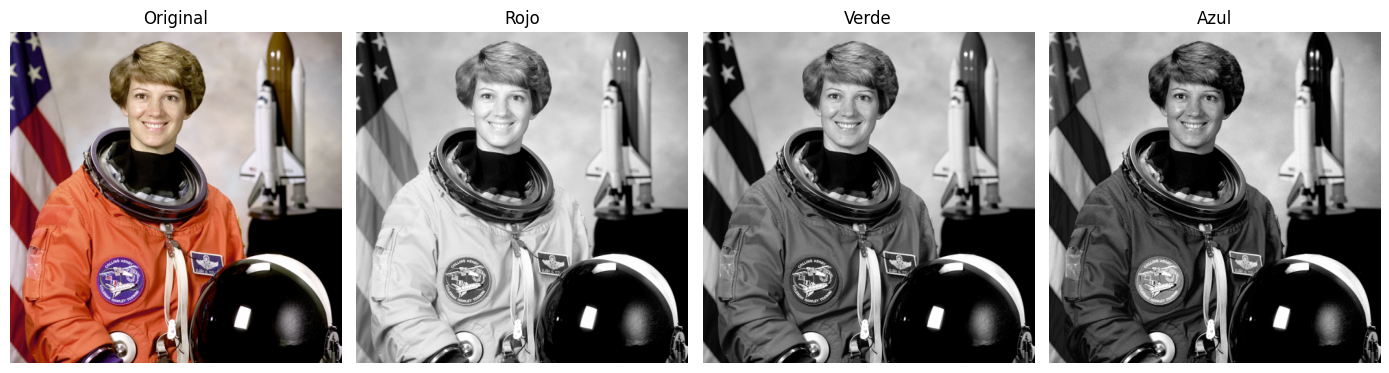

In [4]:
# 1. Cargar la imagen
img_bgr = cv2.imread("paisaje.png")

# 2. Convertirla a RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 3. Extraer canales
canal_rojo = img_rgb[:, :, 0]
canal_verde = img_rgb[:, :, 1]
canal_azul = img_rgb[:, :, 2]

# 4. Visualizar resultados
mostrar_imagenes(
    [img_rgb, canal_rojo, canal_verde, canal_azul],
    ["Original", "Rojo", "Verde", "Azul"],
)


In [5]:
# Escribí acá tu observación sobre los canales.
# ¿Qué zonas aparecen más brillantes en cada uno?

observacion_canales = "Las zonas rojas aparecen mas brillantes en el canal rojo, en el canal verde " \
"las areas que contienen verde se destacan mas y en el canal azul las partes azules aparecen mas brillantes."
print(observacion_canales)


Las zonas rojas aparecen mas brillantes en el canal rojo, en el canal verde las areas que contienen verde se destacan mas y en el canal azul las partes azules aparecen mas brillantes.


## Ejercicio 2: Recorte y redimensionado

1. Definí una región de interés de `100 x 100` píxeles dentro de `paisaje.png`.
2. Redimensioná ese recorte a `220 x 220` píxeles.
3. Armá un mosaico `2 x 2` con el recorte redimensionado.
4. Explicá, con una frase, la diferencia entre recortar y redimensionar.


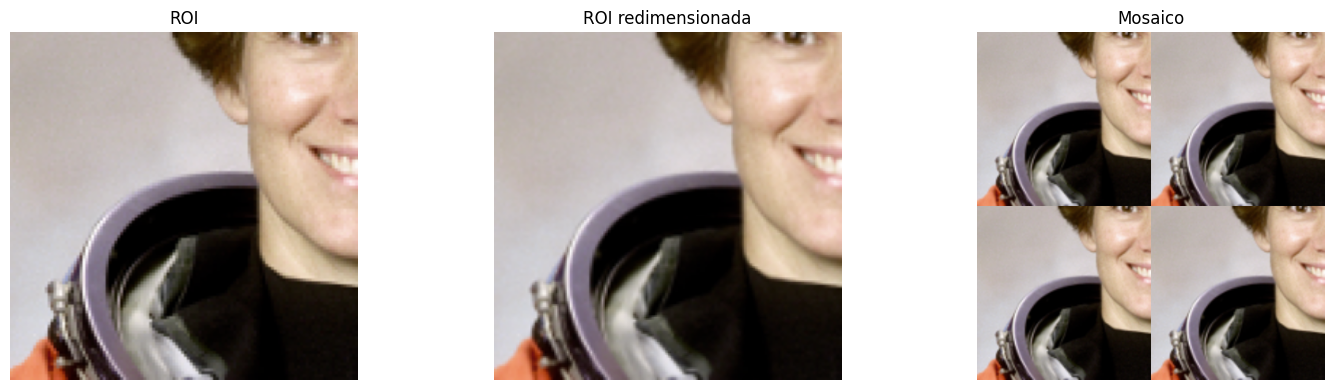

In [6]:
# Definí los índices de tu región de interés.
y1, y2 = 100,220
x1, x2 = 100,220

roi = img_rgb[y1:y2, x1:x2]
roi_grande = cv2.resize(roi, (220, 220))

# Armá un mosaico 2 x 2.
fila_superior = np.hstack([roi_grande, roi_grande])
fila_inferior = np.hstack([roi_grande, roi_grande])
mosaico = np.vstack([fila_superior, fila_inferior])

mostrar_imagenes(
    [roi, roi_grande, mosaico],
    ["ROI", "ROI redimensionada", "Mosaico"],
    figsize=(15, 4),
)


In [7]:
# Explicación breve.
explicacion_geometria = " Recorte original en roi, la imagen con ROI redimensionado se muestra mas grande como un zoom, pierde un poco la nitidez;" \
" respecto a la imagen original y las imagenes mosaicos se ven mas chicas agrupadas."
print(explicacion_geometria)


 Recorte original en roi, la imagen con ROI redimensionado se muestra mas grande como un zoom, pierde un poco la nitidez; respecto a la imagen original y las imagenes mosaicos se ven mas chicas agrupadas.


## Ejercicio 3: Bordes y umbralización

1. Cargá `texto.png` en escala de grises.
2. Aplicá `Canny` con dos pares de umbrales distintos.
3. Cargá `monedas.png` en escala de grises.
4. Segmentá la imagen de monedas con al menos dos umbrales.
5. Compará los resultados y explicá cuál te parece más útil.


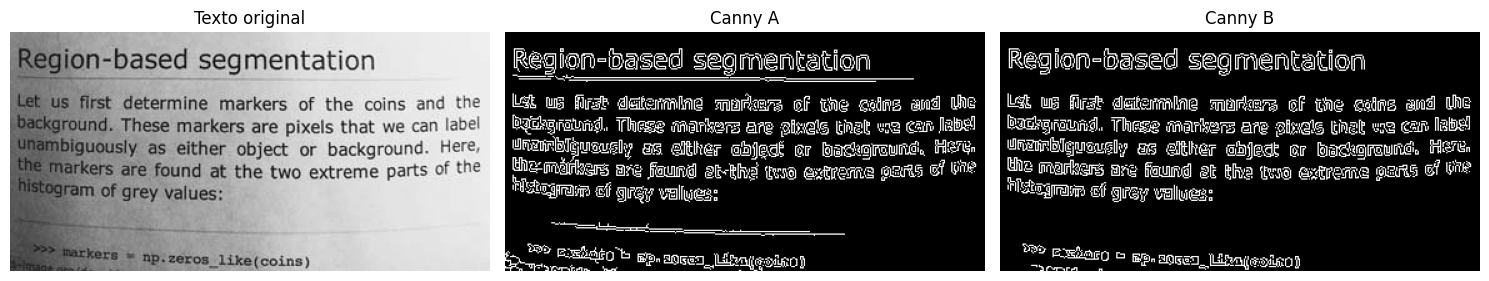

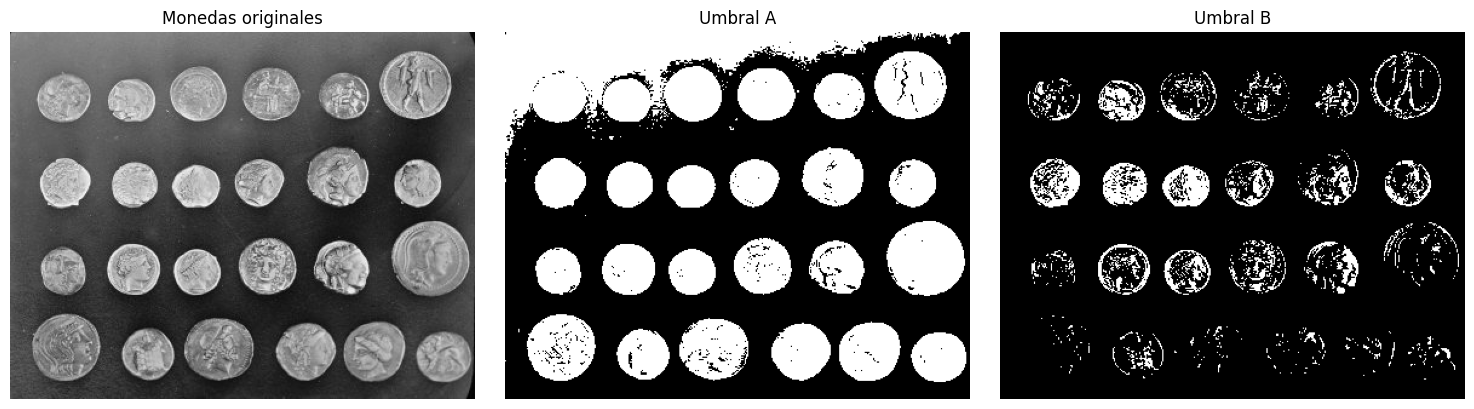

In [8]:
img_texto = cv2.imread("texto.png", cv2.IMREAD_GRAYSCALE)

canny_a = cv2.Canny(img_texto, 50, 150) # mas sensible 
canny_b = cv2.Canny(img_texto, 100, 250) #menos sensible

mostrar_imagenes(
    [img_texto, canny_a, canny_b],
    ["Texto original", "Canny A", "Canny B"],
    figsize=(15, 4),
)

img_monedas = cv2.imread("monedas.png", cv2.IMREAD_GRAYSCALE)

seg_a = segmentar_por_umbral(img_monedas, 100) #umbral bajo
seg_b = segmentar_por_umbral(img_monedas, 180) #umbral alto

mostrar_imagenes(
    [img_monedas, seg_a, seg_b],
    ["Monedas originales", "Umbral A", "Umbral B"],
    figsize=(15, 4),
)


## Cierre breve

Antes de pasar al laboratorio, revisá si podés responder estas preguntas:

- ¿cuándo conviene mirar canales por separado?
- Cuando se necesita segmentar colores especificos. Lo cual es util para detectar objetos por su color.
- ¿qué cambia al modificar los umbrales de `Canny`?
- En el umbral bajo detecta mas bordes, incluyen detalles finos pero con un poco mas de ruido.
- umbral altos, detecta solo bordes mas finos, imagen un poco mas limpias pero con perdida de detalles.
- ¿por qué una segmentación por umbral puede funcionar bien en una imagen y mal en otra?
Depende del contraste entre el objeto y el fondo de la imagen. si ahi superposicion de intensidades la segmentacion incluyes partes no deseadas o ruido o se pierde parte del objeto. Por lo que cada imagen tiene diferente iluminacion.
